In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [163]:
data = pd.read_excel('afrimarket_dataset_senior.xlsx')
data.head()

,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,Mobile Money,Email,1.0,Livrée
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_Beauté_3,37.18,2,0.10,6.89,Paiement à la livraison,Instagram Ads,2026-04-08 00:00:00,Livrée
2,CMD100002,2025-07-08,C0119,Abidjan,electronique,Produit_Électronique_36,315.6,0,0.04,2026-06-05 00:00:00,Carte,Google Ads,2026-03-07 00:00:00,Livrée
3,CMD100003,2025-08-20,C1436,Libreville,electronique,Produit_Électronique_29,143.25,0,0.03,5.96,Mobile Money,Google Ads,2026-02-05 00:00:00,Livrée
4,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_Électronique_45,498.71,2,0.02,5.16,Mobile Money,Email,0.55,Livrée


In [164]:
df = data.copy()
df.shape
# le dataset a 10100 lignes et 14 colonnes

(10100, 14)

In [165]:
print(df.dtypes)
print(df.dtypes.value_counts())
# le dataset a 11 variables qualitatives, 1 variables date, 1 int et 1 float
# Mais, il y a des incoherences comme des variables qui devraient etre quantitative ou 
# des variables qui n'ont pas le meme type

id_commande                 object
date_commande       datetime64[ns]
id_client                   object
ville                       object
categorie                   object
nom_produit                 object
prix_unitaire               object
quantite                     int64
remise                     float64
cout_livraison              object
methode_paiement            object
canal_marketing             object
cout_marketing              object
statut_commande             object
dtype: object
object            11
datetime64[ns]     1
int64              1
float64            1
Name: count, dtype: int64


In [166]:
# les valeurs manquantes
df.isna().sum()
# le datset ne presente pas de valeurs manquantes mais du fait des incoherences alors lors de la
# du data cleaning, ils deviendront des valeus manquantes mais on va proceder a l'imputation

id_commande         0
date_commande       0
id_client           0
ville               0
categorie           0
nom_produit         0
prix_unitaire       0
quantite            0
remise              0
cout_livraison      0
methode_paiement    0
canal_marketing     0
cout_marketing      0
statut_commande     0
dtype: int64

In [169]:
# les doublons
# compter le nombre de doublons
print(df.duplicated().sum())
# il y a 100 doublons qu'il faut supprimer donc il va rester 100000 enregistrements

# suppression des doublons
df = df.drop_duplicates()

0


**resume d'audit**

**1. le dataset ne contient pas des valeurs manquantes mais presente parfois des valeurs de differents types**

**2.il y a des enregistrements doubles**
#### il faudra le normaliser lors du data cleaning

In [170]:
## 1. la standardisation des dates

df['date_commande'] = pd.to_datetime(df['date_commande'], dayfirst = True, errors='coerce')

In [171]:
# uniformisation des categories
# ici, on va uniformiser toutes les colonnes objets
cols_to_fix = ['ville', 'categorie', 'nom_produit', 'methode_paiement', 'canal_marketing', 'statut_commande']

for col in cols_to_fix:
    #on met les mots en miniscules
    # on enleve les espaces au debut et fin de la chaine
    # on peut aussi harmoniser les accents si necessaires
    df[col] = df[col].astype(str).str.lower().str.strip()
    # remplacer les caracteres speciaux ou les accents
    
    df[col] = df[col].str.normalize('NFKD').str.encode('ascii',
                                                      errors = 'ignore').str.decode('utf-8')

for col in cols_to_fix:
    print(f'{col:-<20}, {df[col].unique()}')
    
# les valeurs de kinshassa on les met dans kinshasa
df['ville'].replace(['kinshassa'], ['kinshasa'], inplace = True)

ville---------------, ['brazzaville' 'libreville' 'abidjan' 'dakar' 'lome' 'cotonou' 'kinshasa'
 'douala' 'kinshassa']
categorie-----------, ['mode' 'beaute' 'electronique' 'maison']
nom_produit---------, ['produit_mode_9' 'produit_beaute_3' 'produit_electronique_36'
 'produit_electronique_29' 'produit_electronique_45' 'produit_maison_7'
 'produit_mode_3' 'produit_beaute_41' 'produit_electronique_7'
 'produit_electronique_24' 'produit_electronique_39' 'produit_mode_25'
 'produit_mode_44' 'produit_electronique_21' 'produit_mode_14'
 'produit_maison_38' 'produit_mode_49' 'produit_maison_39'
 'produit_maison_36' 'produit_maison_50' 'produit_beaute_1'
 'produit_electronique_41' 'produit_beaute_39' 'produit_maison_16'
 'produit_beaute_47' 'produit_beaute_9' 'produit_beaute_14'
 'produit_maison_29' 'produit_maison_5' 'produit_mode_43'
 'produit_electronique_16' 'produit_beaute_23' 'produit_beaute_4'
 'produit_mode_13' 'produit_beaute_5' 'produit_mode_42'
 'produit_maison_11' 'produit_beaute_

In [172]:
# transformation en des variables quantitatives
# ici, les valeurs qui presentent des anomalies seront prises comme des valeurs manquantes
col_to_numerize = ['prix_unitaire', 'quantite', 'remise', 'cout_livraison', 'cout_marketing']

for col in col_to_numerize:
    df[col] = pd.to_numeric(df[col], errors = 'coerce')

C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


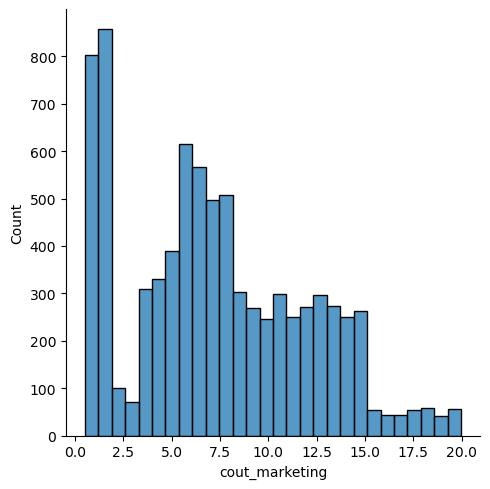

In [173]:
df.dtypes
sns.displot(df['cout_marketing'])

In [155]:
print(df.isna().sum())
print(df.shape)

id_commande            0
date_commande          0
id_client              0
ville                  0
categorie              0
nom_produit            0
prix_unitaire        441
quantite               0
remise                 0
cout_livraison      2008
methode_paiement       0
canal_marketing        0
cout_marketing      1883
statut_commande        0
dtype: int64
(10000, 14)


count    8117.000000
mean        7.300579
std         4.658748
min         0.500000
25%         3.720000
50%         6.780000
75%        10.790000
max        19.980000
Name: cout_marketing, dtype: float64


<Axes: ylabel='cout_marketing'>

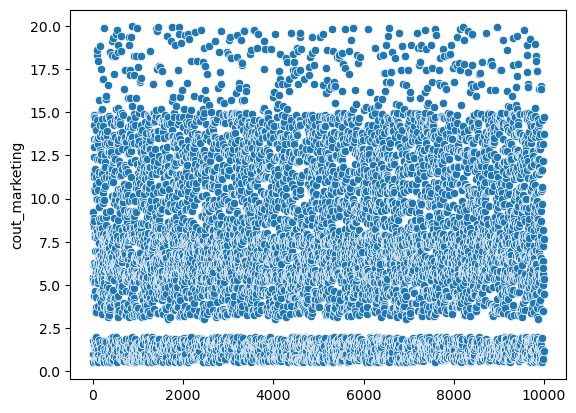

In [156]:
df['prix_unitaire'] = df['prix_unitaire'].abs()
print(df['cout_marketing'].describe())
sns.scatterplot(df['cout_marketing'])

In [157]:
# du fait que l'imputation avec moyenne sur les prix pourrait nous donner des fausses informations car 
# il y des valeurs qui sont trop elevees
# , on va les supprimer ces valeurs manquantes et par chance ils ne sont pas elevees

df

,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,brazzaville,mode,produit_mode_9,49.72,3,0.07,2.45,mobile money,email,1.00,livree
1,CMD100001,2025-07-27,C1827,libreville,beaute,produit_beaute_3,37.18,2,0.10,6.89,paiement a la livraison,instagram ads,NaN,livree
2,CMD100002,2025-07-08,C0119,abidjan,electronique,produit_electronique_36,315.60,0,0.04,NaN,carte,google ads,NaN,livree
3,CMD100003,2025-08-20,C1436,libreville,electronique,produit_electronique_29,143.25,0,0.03,5.96,mobile money,google ads,NaN,livree
4,CMD100004,2025-11-28,C0003,libreville,electronique,produit_electronique_45,498.71,2,0.02,5.16,mobile money,email,0.55,livree
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CMD109995,2025-11-01,C0394,lome,beaute,produit_beaute_14,15.73,3,0.01,3.48,mobile money,influenceur,7.66,livree
9996,CMD109996,2025-08-30,C0022,dakar,beaute,produit_beaute_8,29.94,3,0.05,4.92,virement,influenceur,4.45,livree
9997,CMD109997,2025-10-29,C0188,douala,electronique,produit_electronique_6,521.98,1,0.25,3.54,paiement a la livraison,instagram ads,14.72,livree
9998,CMD109998,2025-07-11,C0103,abidjan,mode,produit_mode_39,71.24,0,0.21,4.58,virement,email,1.15,retournee


In [158]:
df = df.dropna(subset=['prix_unitaire'])

In [159]:
df.shape

(9559, 14)

<Axes: >

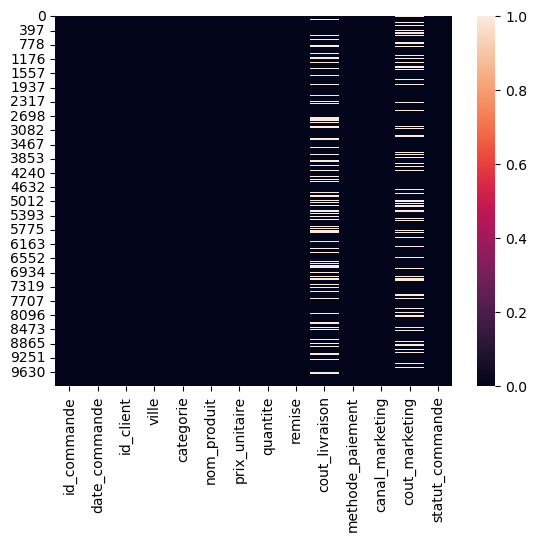

In [160]:
sns.heatmap(df.isna())

In [161]:
from sklearn.impute import KNNImputer
col_impute = ['cout_livraison', 'cout_marketing']
impute = KNNImputer(n_neighbors = 4)

df[col_impute] = impute.fit_transform(df[col_impute])

C:\Users\DELL LATITUDE\AppData\Local\Temp\ipykernel_10584\838015313.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col_impute] = impute.fit_transform(df[col_impute])


In [134]:
df.isna().sum()

id_commande         0
date_commande       0
id_client           0
ville               0
categorie           0
nom_produit         0
prix_unitaire       0
quantite            0
remise              0
cout_livraison      0
methode_paiement    0
canal_marketing     0
cout_marketing      0
statut_commande     0
dtype: int64

In [137]:
df.shape

(9559, 14)

In [138]:
df.head()

,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,brazzaville,mode,produit_mode_9,49.72,3,0.07,2.450000,mobile money,email,1.000000,livree
1,CMD100001,2025-07-27,C1827,libreville,beaute,produit_beaute_3,37.18,2,0.10,6.890000,paiement a la livraison,instagram ads,5.085000,livree
2,CMD100002,2025-07-08,C0119,abidjan,electronique,produit_electronique_36,315.60,0,0.04,6.045641,carte,google ads,7.283751,livree
3,CMD100003,2025-08-20,C1436,libreville,electronique,produit_electronique_29,143.25,0,0.03,5.960000,mobile money,google ads,8.662500,livree
4,CMD100004,2025-11-28,C0003,libreville,electronique,produit_electronique_45,498.71,2,0.02,5.160000,mobile money,email,0.550000,livree


C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


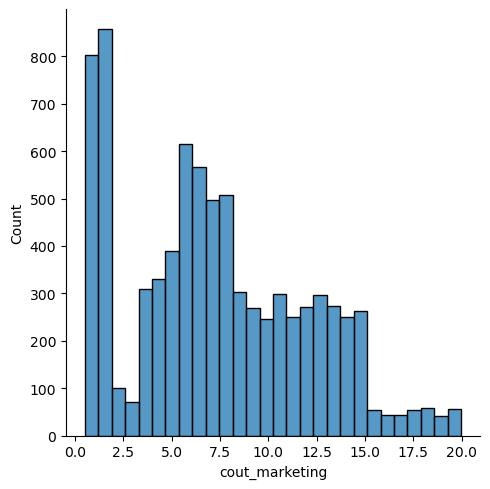

In [152]:
sns.displot(df['cout_marketing'])

In [174]:
df.shape

(10000, 14)